In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="C4TS8wU6nQwtuOZiJCYT")
project = rf.workspace("datasetteh").project("bidang-panjang-60-derajat")
version = project.version(1)
dataset = version.download("folder")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset.location + "/train",
    image_size=(64,64),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset.location + "/valid",
    image_size=(64,64),
    batch_size=32
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 444 files belonging to 4 classes.
Found 36 files belonging to 4 classes.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(64,64,3)),

    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 236ms/step - accuracy: 0.2793 - loss: 1.3780 - val_accuracy: 0.4167 - val_loss: 1.3292
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 246ms/step - accuracy: 0.4189 - loss: 1.2385 - val_accuracy: 0.4167 - val_loss: 1.2193
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.4369 - loss: 1.1614 - val_accuracy: 0.2500 - val_loss: 1.2658
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - accuracy: 0.4437 - loss: 1.1872 - val_accuracy: 0.3056 - val_loss: 1.2312
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.4437 - loss: 1.1743 - val_accuracy: 0.3056 - val_loss: 1.2313
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.5023 - loss: 1.1440 - val_accuracy: 0.3889 - val_loss: 1.1664
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.4887 - loss: 1.1114 - val_accuracy: 0.3611 - val_loss: 1.1279
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 265ms/step - accuracy: 0.4459 - loss: 1.1204 - val_accuracy: 0.

In [ ]:
model.evaluate(val_ds)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3611 - loss: 1.2081


[1.2081201076507568, 0.3611111044883728]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


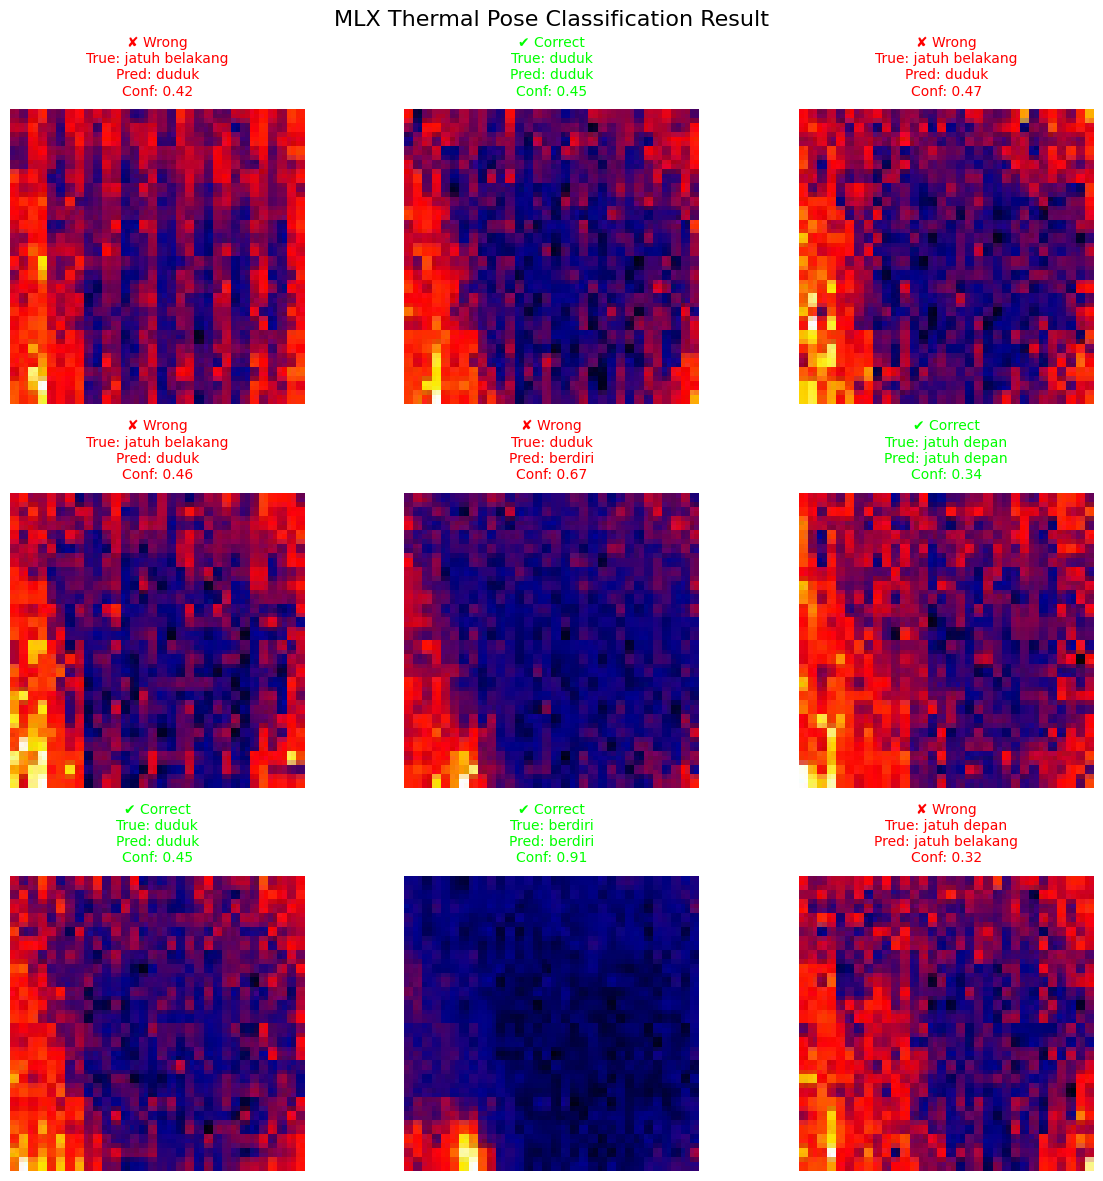

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in val_ds.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(12,12))

    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        img = images[i].numpy()

        # ===== FIX THERMAL =====
        if img.shape[-1] == 1:
            img = img.squeeze()

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        ax.imshow(img, cmap='inferno')
        ax.axis("off")
        # =======================

        true_label = class_names[labels[i]]
        pred_label = class_names[pred_labels[i]]
        confidence = np.max(preds[i])

        # ===== STATUS =====
        if true_label == pred_label:
            color = "lime"
            status = "✔ Correct"
        else:
            color = "red"
            status = "✘ Wrong"

        # border warna
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

        # title
        ax.set_title(
            f"{status}\nTrue: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}",
            fontsize=10,
            color=color,
            pad=10
        )

    plt.suptitle("MLX Thermal Pose Classification Result", fontsize=16)
    plt.tight_layout()
    plt.show()

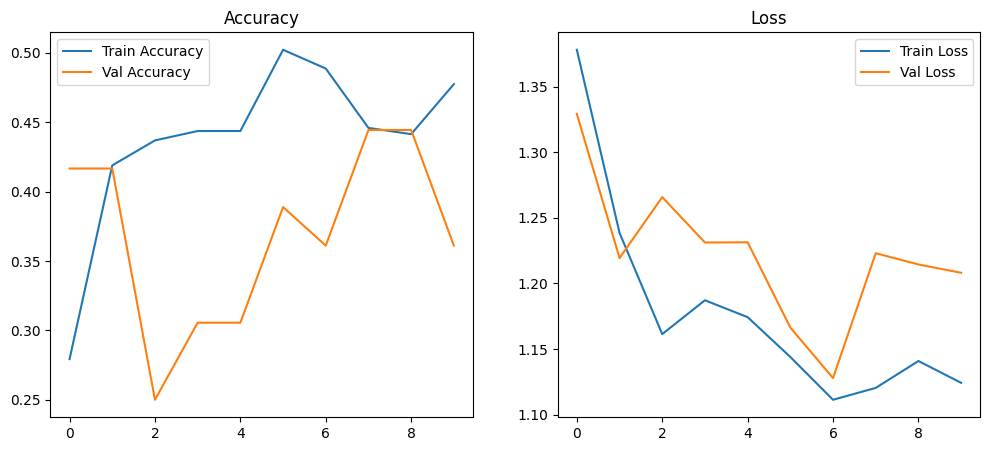

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.figure(figsize=(12,5))

# ===== ACCURACY =====
plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

# ===== LOSS =====
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()